# 07 — SAGA & ELVES satellite anisotropy: MCMC fits and selection variations

This notebook looks **only at the observed surveys** (SAGA DR3 and ELVES — no TNG) and fits the
**azimuthal anisotropy** of the satellite distribution with MCMC, then explores how the result
moves under several selection variations. For every run we keep track of the **number of hosts and
satellites**.

### What is fit
For each satellite we have its projected azimuthal angle $\theta\in[0,90]$ from the host major axis
($0^\circ$ = major axis, $90^\circ$ = minor axis). We fit the **unbinned** distribution with

$$p(\theta)\;\propto\;1 + A\,\cos 2\theta,\qquad \theta\in[0,\pi/2],$$

so $A>0$ means an **excess along the major axis** (alignment), $A<0$ an excess along the minor
axis, and $A=0$ is isotropic. $A$ is sampled with `emcee` and is the headline metric, reported
uniformly across every variation.

Where both quenched and star-forming satellites are present (all runs here) we **additionally**
report the quench-fraction sinusoid $f_q(\theta)=a+b\cos 2\theta$ (same model as `03_analysis`), so
this notebook also reproduces the quench-anisotropy fit for the observations.

### Variations explored
**SAGA** — DR3 satellites are graded Gold (1), Silver (2), Participation (3):
1. Gold only  2. Gold + Silver  3. Gold + Silver + Participation.

**ELVES** — five hosts are themselves early-type galaxies (`Early_type_host?` in the host table:
NGC1023, NGC3115, NGC3379, M104, Cen A; the first four have in-$R_{200}$ satellites here). We run:
4. all hosts  5. early-type hosts (and their entire satellite populations) removed. The satellite
quenched proxy is still early-type morphology (`ETG?`), so the quench-fraction fit stays defined.

**Inclination (both surveys)** — a too-face-on host has no well-defined major axis, so we add a cut
removing nearly face-on hosts and refit. Inclination is from the host axis ratio $b/a$
(thin-disk $\cos i = b/a$): SAGA from the DR3 host table, ELVES from SIMBAD. We keep hosts with
$i \ge i_{\min}$.

Requires internet (SIMBAD) for the ELVES host position angles and axis ratios, exactly like
`03_analysis`. TNG is not used. Masses are physical $M_\odot$ (see `../docs/conventions.md`).

In [1]:
import warnings
import numpy as np
import pandas as pd
import emcee
import scipy.stats as stats
import matplotlib as mpl
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad

warnings.filterwarnings("ignore")
%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# --- configuration -----------------------------------------------------------
SAGA_DIR  = "../data/saga"
ELVES_DIR = "../data/elves"

INCL_MIN_DEG = 30.0          # inclination cut: keep hosts with i >= this (drop too-face-on)
                             # thin-disk cos(i) = b/a  ->  keep hosts with b/a <= cos(INCL_MIN_DEG)
BA_MAX = np.cos(np.radians(INCL_MIN_DEG))
print(f"inclination cut: i >= {INCL_MIN_DEG:.0f} deg  ==  b/a <= {BA_MAX:.3f}")

# 18 angle bins over [0, 90] (used only for the P(theta) plots / quench-fraction fit)
N_BINS        = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])

SAGA_C, ELVES_C = "#1f77b4", "#d62728"

inclination cut: i >= 30 deg  ==  b/a <= 0.866


## Shared helpers

`map_to_0_90` folds an azimuthal angle into $[0,90]$ using the ellipse's four-fold symmetry;
`calc_r200` gives $R_{200c}$ from a halo mass.

In [2]:
def map_to_0_90(angles):
    """Fold angles (deg) into [0, 90] using the ellipse four-fold symmetry."""
    a = np.mod(np.asarray(angles, dtype=float), 360.0)
    return np.where(a <= 90, a,
           np.where(a <= 180, 180 - a,
           np.where(a <= 270, a - 180, 360 - a)))

def calc_r200(mhalo_msun):
    """R_200c [kpc] for a halo of mass mhalo_msun [M_sun]. (from J. Zhu)"""
    import astropy.constants as const
    from astropy.cosmology import Planck18 as cosmo
    mhalo = np.asarray(mhalo_msun) * u.Msun
    rho_c = cosmo.critical_density0
    r200c = ((3 * mhalo / (4 * np.pi * 200.0 * rho_c)) ** (1 / 3)).to(u.kpc)
    return r200c.value

def incl_from_ba(ba):
    """Inclination [deg] from axis ratio b/a, thin disk: cos(i) = b/a."""
    ba = np.clip(np.asarray(ba, dtype=float), 0.0, 1.0)
    return np.degrees(np.arccos(ba))

## The MCMC anisotropy fit

Unbinned log-likelihood for $p(\theta)\propto 1+A\cos2\theta$ on $[0,\pi/2]$ (the $\cos2\theta$
term integrates to zero over this range, so the normalization is constant in $A$ and drops out).
`emcee` samples the single parameter $A$ with a flat prior on $(-1,1)$. We also keep a binned
bootstrap + sinusoid fit of the quench fraction (identical to `03_analysis`) for the runs that have
both quenched and star-forming satellites.

In [3]:
# ---- unbinned anisotropy amplitude A -----------------------------------------
def fit_anisotropy(theta_deg, n_walkers=16, n_steps=4000, burn=1000, seed=0):
    """MCMC of p(theta) ~ 1 + A cos(2 theta). Returns dict with A median/std/percentiles."""
    th = np.radians(np.asarray(theta_deg, dtype=float))
    c2 = np.cos(2 * th)
    n = len(th)
    if n < 5:
        return dict(n=n, A=np.nan, Aerr=np.nan, lo=np.nan, hi=np.nan, chain=None)

    def log_prob(p):
        A = p[0]
        if not (-0.999 < A < 0.999):
            return -np.inf
        v = 1.0 + A * c2
        if np.any(v <= 0):
            return -np.inf
        return np.sum(np.log(v))

    rng = np.random.default_rng(seed)
    p0 = rng.uniform(-0.1, 0.1, size=(n_walkers, 1))
    sampler = emcee.EnsembleSampler(n_walkers, 1, log_prob)
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)[:, 0]
    lo, med, hi = np.percentile(chain, [16, 50, 84])
    return dict(n=n, A=med, Aerr=chain.std(), lo=lo, hi=hi, chain=chain)

# ---- quench fraction f_q = a + b cos(2 theta) (as in notebook 03) -------------
def bootstrap_fq(angle, quenched, N=5000, seed=0):
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

def _fq_log_prob(theta, x, y, sigma):
    a, b, f = theta
    if not (0 < a < 1 and -1 < b < 1 and -10 < f < 2):
        return -np.inf
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def fit_fq_sinusoid(mean, std, n_walkers=20, n_steps=6000, burn=1000, seed=0):
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    if ok.sum() < 4:
        return np.array([np.nan]*3), np.array([np.nan]*3)
    p0 = np.array([0.5, 0.0, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, _fq_log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

## SAGA: per-satellite angle, quench, host, and host axis ratio

Join the DR3 host (Table C1) and satellite (Table C3) tables, compute each satellite's projected
angle from its host major axis (same convention as `03_analysis`), the $R_{200c}$ membership, and
carry the host axis ratio `ba` for the inclination cut and the `sample` grade (1/2/3).

In [4]:
saga_hosts = Table.read(f"{SAGA_DIR}/saga-dr3-tableC1.txt", format="ascii.cds")
saga_sats  = Table.read(f"{SAGA_DIR}/saga-dr3-tableC3.txt", format="ascii.cds")
print("SAGA hosts:", len(saga_hosts), "| satellites:", len(saga_sats))

# host lookups by HOSTID
h_idx  = {saga_hosts["HOSTID"][m]: m for m in range(len(saga_hosts))}
h_logM = {saga_hosts["HOSTID"][m]: float(saga_hosts["log(Mhalo)"][m]) for m in range(len(saga_hosts))}
h_ba   = {saga_hosts["HOSTID"][m]: float(saga_hosts["ba"][m]) for m in range(len(saga_hosts))}

# per-satellite arrays
n = len(saga_sats)
saga_theta = np.full(n, np.nan)
saga_r200  = np.full(n, np.nan)
saga_ba    = np.full(n, np.nan)
for k in range(n):
    hid = saga_sats["HOSTID"][k]
    m = h_idx.get(hid)
    if m is None:
        continue
    h_c = SkyCoord(saga_hosts["RAdeg"][m], saga_hosts["DEdeg"][m], frame="icrs", unit="deg")
    s_c = SkyCoord(saga_sats["RAdeg"][k], saga_sats["DEdeg"][k], frame="icrs", unit="deg")
    PA  = float(saga_hosts["PA"][m])
    rel = h_c.position_angle(s_c).degree
    saga_theta[k] = map_to_0_90(((90 - PA) + (90 + rel)) % 360)
    saga_r200[k]  = calc_r200(10 ** h_logM[hid])
    saga_ba[k]    = h_ba[hid]

saga = pd.DataFrame({
    "host":     np.asarray(saga_sats["HOSTID"]),
    "theta":    saga_theta,
    "quenched": np.asarray(saga_sats["quenched"], dtype=float),
    "sample":   np.asarray(saga_sats["sample"], dtype=int),     # 1=Gold 2=Silver 3=Participation
    "Rhost":    np.asarray(saga_sats["Rhost"], dtype=float),
    "r200":     saga_r200,
    "ba":       saga_ba,
})
saga["in_r200"] = saga["Rhost"] < saga["r200"]
print("within R200:", int(saga["in_r200"].sum()), "/", len(saga))

SAGA hosts: 101 | satellites: 378
within R200: 284 / 378


## ELVES: per-satellite angle, quench (ETG), host PA and axis ratio from SIMBAD

Host position angle **and** axis ratio come from SIMBAD (`GALDIM_*`); the local host CSV's
`Inclination`/`Position_angle` columns are empty. We keep only satellites within $R_{200}$
(`Rproj_in_Rvir? == 1`) to mirror SAGA. The satellite quenched flag is early-type morphology
(`ETG?`). We also read the host catalog's `Early_type_host?` flag to identify the early-type
**hosts** (removed as a group in one of the variations below).

In [5]:
elves_sats  = pd.read_csv(f"{ELVES_DIR}/Carlsten22_ELVES_confirmed_sats.csv")
elves_hosts = pd.read_csv(f"{ELVES_DIR}/Carlsten22_ELVES_host.csv")
# early-type host galaxies (their whole satellite populations are dropped in one variation)
ETG_HOSTS = set(elves_hosts.loc[elves_hosts["Early_type_host?"] == True, "Host"].astype(str))
print("ELVES confirmed satellites:", len(elves_sats))
print("early-type hosts (Early_type_host?):", sorted(ETG_HOSTS))

_S = Simbad(); _S.reset_votable_fields()
for f in ("dim_majaxis", "dim_minaxis", "dim_angle"):
    try: _S.add_votable_fields(f)
    except Exception: pass

def _val(t, key):
    for c in t.colnames:
        if key in c.lower():
            v = t[c][0]
            try:
                if v is None or np.ma.is_masked(v):
                    return np.nan
                return float(v)
            except (TypeError, ValueError):
                return np.nan
    return np.nan

def _galdim_angle(t):
    """Galaxy major-axis PA [deg] from SIMBAD GALDIM_ANGLE. NaN if unavailable.

    NB: match GALDIM_ANGLE specifically -- a bare "angle" substring also matches
    COO_ERR_ANGLE (the coordinate error-ellipse PA), which is the wrong field and,
    when masked, silently drops the host and nan-poisons the anisotropy/quench fit.
    """
    if t is None:
        return np.nan
    col = next((c for c in t.colnames if "galdim" in c.lower() and "angle" in c.lower()), None)
    if col is None:                                    # newer astroquery TAP names it 'pa'
        col = next((c for c in t.colnames if c.lower() in ("pa", "galdim_pa")), None)
    if col is None:
        return np.nan
    v = t[col][0]
    try:
        return np.nan if (v is None or np.ma.is_masked(v)) else float(v)
    except (TypeError, ValueError):
        return np.nan

def simbad_host(name):
    """Return (PA_deg, b/a, SkyCoord) for a host, using SIMBAD; NaN/None when unavailable."""
    try:
        t = _S.query_object(name)
    except Exception:
        t = None
    pa = ba = np.nan
    if t is not None:
        pa  = _galdim_angle(t)            # GALDIM_ANGLE, not COO_ERR_ANGLE (see helper)
        maj = _val(t, "majaxis"); mn = _val(t, "minaxis")
        if np.isfinite(maj) and np.isfinite(mn) and maj > 0:
            ba = mn / maj
    try:
        coord = SkyCoord.from_name(name)
    except Exception:
        coord = None
    return pa, ba, coord

host_info = {h: simbad_host(h) for h in elves_sats["Host"].unique()}
resolved = sum(c is not None and np.isfinite(pa) for pa, ba, c in host_info.values())
print("ELVES hosts:", len(host_info), "| with SIMBAD PA + coord:", resolved)

ELVES confirmed satellites: 251
early-type hosts (Early_type_host?): ['CEN A', 'M104', 'NGC1023', 'NGC3115', 'NGC3379']
ELVES hosts: 25 | with SIMBAD PA + coord: 25


In [6]:
rows = []
for r in range(len(elves_sats)):
    if elves_sats["Rproj_in_Rvir?"].iloc[r] != 1:          # within R200 only
        continue
    host = elves_sats["Host"].iloc[r]
    PA, ba, h_c = host_info.get(host, (np.nan, np.nan, None))
    if h_c is None or not np.isfinite(PA):
        continue
    s_c = SkyCoord(ra=elves_sats["RA(deg)"].iloc[r], dec=elves_sats["DEC(deg)"].iloc[r],
                   frame="icrs", unit="deg")
    rel = h_c.position_angle(s_c).degree
    rows.append((host,
                 float(map_to_0_90(((90 - PA) + rel + 90) % 360)),
                 float(elves_sats["ETG?"].iloc[r]),
                 ba,
                 host in ETG_HOSTS))

elves = pd.DataFrame(rows, columns=["host", "theta", "quenched", "ba", "host_etg"])
elves = elves.astype({"theta": float, "quenched": float, "ba": float})
print("ELVES within R200 with host PA:", len(elves),
      "| hosts:", elves["host"].nunique(),
      "| sat ETG fraction:", round(elves["quenched"].mean(), 3))
print("early-type hosts present:", sorted(elves.loc[elves["host_etg"], "host"].unique()),
      "->", int(elves["host_etg"].sum()), "satellites")

ELVES within R200 with host PA: 202 | hosts: 24 | sat ETG fraction: 0.693
early-type hosts present: ['M104', 'NGC1023', 'NGC3115', 'NGC3379'] -> 69 satellites


## Run definitions

A *run* is a sample selection. `select_saga` filters by satellite grade set and (optionally) an
inclination cut; `select_elves` optionally drops ETGs and (optionally) applies the inclination cut.
Both always apply the $R_{200}$ membership cut.

In [7]:
def select_saga(grades, incl_cut=False):
    df = saga[saga["in_r200"] & saga["sample"].isin(grades) & np.isfinite(saga["theta"])]
    if incl_cut:
        df = df[df["ba"] <= BA_MAX]
    return df.reset_index(drop=True)

def select_elves(drop_etg_hosts=False, incl_cut=False):
    df = elves[np.isfinite(elves["theta"])].copy()
    if incl_cut:
        df = df[np.isfinite(df["ba"]) & (df["ba"] <= BA_MAX)]
    if drop_etg_hosts:
        df = df[~df["host_etg"]]                       # drop early-type hosts + their satellites
    return df.reset_index(drop=True)

# (label, survey, selector) -- the full set of variations
RUNS = [
    ("SAGA Gold",                 "SAGA",  lambda: select_saga({1})),
    ("SAGA Gold+Silver",          "SAGA",  lambda: select_saga({1, 2})),
    ("SAGA Gold+Silver+Part",     "SAGA",  lambda: select_saga({1, 2, 3})),
    ("SAGA Gold (incl cut)",      "SAGA",  lambda: select_saga({1}, incl_cut=True)),
    ("SAGA G+S+P (incl cut)",     "SAGA",  lambda: select_saga({1, 2, 3}, incl_cut=True)),
    ("ELVES all hosts",           "ELVES", lambda: select_elves(drop_etg_hosts=False)),
    ("ELVES late-type hosts",     "ELVES", lambda: select_elves(drop_etg_hosts=True)),
    ("ELVES all (incl cut)",      "ELVES", lambda: select_elves(drop_etg_hosts=False, incl_cut=True)),
    ("ELVES late-type (incl cut)","ELVES", lambda: select_elves(drop_etg_hosts=True,  incl_cut=True)),
]

## Run every variation

For each run we record the host/satellite counts, fit the anisotropy amplitude $A$ (for all
satellites and, where present, separately for the quenched and star-forming subsets), and — when
both classes are present — fit the quench-fraction sinusoid. KS test vs uniform is reported as an
independent isotropy check.

In [8]:
def run_one(df):
    th  = df["theta"].to_numpy()
    q   = df["quenched"].to_numpy()
    res = dict(
        n_host=df["host"].nunique(), n_sat=len(df),
        n_q=int((q == 1).sum()), n_sf=int((q == 0).sum()),
        fit_all=fit_anisotropy(th, seed=1),
        fit_q  =fit_anisotropy(th[q == 1], seed=2),
        fit_sf =fit_anisotropy(th[q == 0], seed=3),
        ks=stats.kstest(th, "uniform", args=(0, 90)).pvalue if len(th) >= 5 else np.nan,
        theta=th, q=q,
    )
    # quench-fraction sinusoid only when both classes present (drop unmeasured quench)
    if res["n_q"] > 0 and res["n_sf"] > 0:
        ok = np.isfinite(q)
        m, s = bootstrap_fq(th[ok], q[ok])
        res["fq_mean"], res["fq_std"] = m, s
        res["fq_p"], res["fq_e"] = fit_fq_sinusoid(m, s)
    else:
        res["fq_mean"] = res["fq_std"] = res["fq_p"] = res["fq_e"] = None
    return res

results = {}
for label, survey, sel in RUNS:
    results[label] = run_one(sel())
    results[label]["survey"] = survey
    r = results[label]
    print(f"{label:<26s} hosts={r['n_host']:>3d}  sats={r['n_sat']:>4d}  "
          f"(q={r['n_q']:>3d}, sf={r['n_sf']:>3d})  "
          f"A={r['fit_all']['A']:+.3f} +/- {r['fit_all']['Aerr']:.3f}")

SAGA Gold                  hosts= 78  sats= 184  (q= 47, sf=137)  A=-0.095 +/- 0.107
SAGA Gold+Silver           hosts= 92  sats= 269  (q= 76, sf=193)  A=-0.106 +/- 0.084
SAGA Gold+Silver+Part      hosts= 94  sats= 284  (q= 78, sf=206)  A=-0.125 +/- 0.082
SAGA Gold (incl cut)       hosts= 71  sats= 167  (q= 44, sf=123)  A=-0.121 +/- 0.109
SAGA G+S+P (incl cut)      hosts= 84  sats= 257  (q= 74, sf=183)  A=-0.119 +/- 0.086
ELVES all hosts            hosts= 24  sats= 202  (q=140, sf= 62)  A=+0.045 +/- 0.097
ELVES late-type hosts      hosts= 20  sats= 133  (q= 84, sf= 49)  A=+0.062 +/- 0.118
ELVES all (incl cut)       hosts= 19  sats= 141  (q= 97, sf= 44)  A=+0.030 +/- 0.113
ELVES late-type (incl cut) hosts= 17  sats= 113  (q= 71, sf= 42)  A=+0.050 +/- 0.128


## Summary table — counts and fits for every run

`A` is the anisotropy amplitude ($+$ = major-axis excess). `A_q`/`A_sf` are the same for the
quenched / star-forming subsets. `b` is the quench-fraction sinusoid amplitude with its
significance $|b|/\sigma_b$ (blank where one satellite class is absent).

In [9]:
def fmt(fit):
    return "n/a" if fit is None or not np.isfinite(fit["A"]) else f"{fit['A']:+.3f}+/-{fit['Aerr']:.3f}"

rows = []
for label, _, _ in RUNS:
    r = results[label]
    if r["fq_p"] is not None and np.isfinite(r["fq_p"][1]):
        b = f"{r['fq_p'][1]:+.3f}"; bsig = f"{abs(r['fq_p'][1] / r['fq_e'][1]):.2f}"
    else:
        b = bsig = ""
    rows.append({
        "run": label, "survey": r["survey"],
        "hosts": r["n_host"], "sats": r["n_sat"], "n_q": r["n_q"], "n_sf": r["n_sf"],
        "A (all)": fmt(r["fit_all"]), "A_q": fmt(r["fit_q"]), "A_sf": fmt(r["fit_sf"]),
        "|A|/sig": (f"{abs(r['fit_all']['A'] / r['fit_all']['Aerr']):.2f}"
                    if np.isfinite(r["fit_all"]["A"]) else "n/a"),
        "fq b": b, "|b|/sig_b": bsig, "KS p": f"{r['ks']:.3f}",
    })
summary = pd.DataFrame(rows).set_index("run")
summary

,survey,hosts,sats,n_q,n_sf,A (all),A_q,A_sf,|A|/sig,fq b,|b|/sig_b,KS p
run,,,,,,,,,,,,
SAGA Gold,SAGA,78,184,47,137,-0.095+/-0.107,-0.224+/-0.196,-0.050+/-0.124,0.88,+0.002,0.04,0.536
SAGA Gold+Silver,SAGA,92,269,76,193,-0.106+/-0.084,-0.227+/-0.147,-0.050+/-0.103,1.27,-0.037,0.91,0.153
SAGA Gold+Silver+Part,SAGA,94,284,78,206,-0.125+/-0.082,-0.222+/-0.148,-0.086+/-0.100,1.51,-0.026,0.66,0.059
SAGA Gold (incl cut),SAGA,71,167,44,123,-0.121+/-0.109,-0.182+/-0.199,-0.088+/-0.130,1.11,+0.021,0.37,0.384
SAGA G+S+P (incl cut),SAGA,84,257,74,183,-0.119+/-0.086,-0.173+/-0.151,-0.091+/-0.104,1.38,-0.015,0.35,0.079
ELVES all hosts,ELVES,24,202,140,62,+0.045+/-0.097,+0.086+/-0.115,-0.039+/-0.166,0.46,+0.057,1.12,0.464
ELVES late-type hosts,ELVES,20,133,84,49,+0.062+/-0.118,+0.105+/-0.144,+0.003+/-0.196,0.52,+0.032,0.36,0.698
ELVES all (incl cut),ELVES,19,141,97,44,+0.030+/-0.113,+0.070+/-0.134,-0.041+/-0.199,0.27,+0.054,1.00,0.407
ELVES late-type (incl cut),ELVES,17,113,71,42,+0.050+/-0.128,+0.097+/-0.157,-0.036+/-0.206,0.39,+0.048,0.72,0.687


## Plot 1 — anisotropy amplitude $A$ across all runs (forest plot)

Each run's $A$ with its 16-84% interval. The vertical line at $A=0$ is isotropy; points to the
right indicate a major-axis excess. Annotations give the host/satellite counts so the effect of
each cut on sample size is visible at a glance.

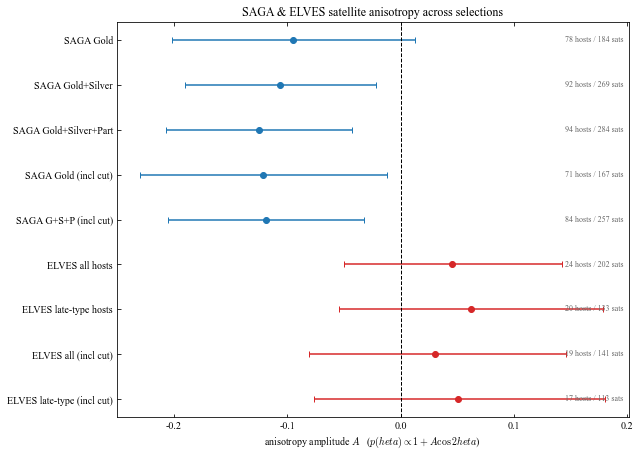

In [10]:
labels = [l for l, _, _ in RUNS][::-1]                 # top-to-bottom = first-to-last
ys = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels) + 1.5))
for y, lab in zip(ys, labels):
    r = results[lab]; f = r["fit_all"]
    col = SAGA_C if r["survey"] == "SAGA" else ELVES_C
    if np.isfinite(f["A"]):
        ax.errorbar(f["A"], y, xerr=[[f["A"] - f["lo"]], [f["hi"] - f["A"]]],
                    fmt="o", color=col, capsize=3, ms=6)
    ax.text(0.99, y, f"{r['n_host']} hosts / {r['n_sat']} sats", transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=8, color="0.4")
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_yticks(ys); ax.set_yticklabels(labels)
ax.set_xlabel(r"anisotropy amplitude $A$   ($p(	heta)\propto 1 + A\cos 2	heta$)")
ax.set_title("SAGA & ELVES satellite anisotropy across selections")
ax.tick_params(which="both", direction="in", top=True)
ax.margins(y=0.05)
plt.tight_layout(); plt.show()

## Plot 2 — $P(\theta)$ with the fitted anisotropy model

Stepped histogram = observed normalized angular distribution; smooth curve = the MCMC posterior
median $p(\theta)=\frac{1}{90}(1+A\cos2\theta)$. Left: the three SAGA grade sets. Right: ELVES with
all hosts vs early-type hosts removed. Flat is isotropic; a slope toward $\theta=0$ is alignment.

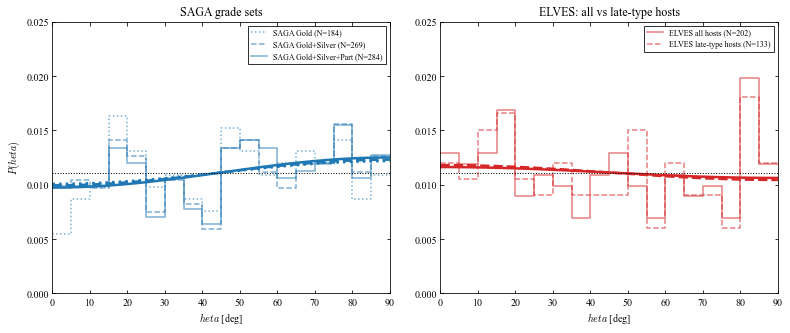

In [11]:
def norm_hist(theta):
    c, _ = np.histogram(theta, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

def model_curve(A):
    x = np.linspace(0, 90, 200)
    return x, (1.0 / 90.0) * (1.0 + A * np.cos(2 * np.radians(x)))

groups = [
    ("SAGA grade sets", SAGA_C,
     [("SAGA Gold", ":"), ("SAGA Gold+Silver", "--"), ("SAGA Gold+Silver+Part", "-")]),
    ("ELVES: all vs late-type hosts", ELVES_C,
     [("ELVES all hosts", "-"), ("ELVES late-type hosts", "--")]),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, col, items) in zip(axes, groups):
    for lab, ls in items:
        r = results[lab]
        h = norm_hist(r["theta"])
        ax.step(ANGLE_EDGES, np.r_[h, h[-1]], where="post", color=col, ls=ls, lw=1.5, alpha=0.6,
                label=f"{lab} (N={r['n_sat']})")
        if np.isfinite(r["fit_all"]["A"]):
            x, y = model_curve(r["fit_all"]["A"])
            ax.plot(x, y, color=col, ls=ls, lw=2.5)
    ax.axhline(1 / 90, color="k", lw=1, ls=":")            # isotropic level
    ax.set_xlim(0, 90); ax.set_ylim(0, 0.025); ax.set_xlabel(r"$	heta$ [deg]")
    ax.set_title(title); ax.legend(fontsize=8, fancybox=False, edgecolor="k")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$P(	heta)$")
plt.subplots_adjust(wspace=0.15); plt.show()

## Plot 3 — effect of the inclination cut

Compare $A$ with and without the too-face-on hosts removed, for the SAGA Gold+Silver+Participation
and ELVES (with ETGs) samples. Removing face-on hosts (no well-defined major axis) should, if the
signal is real, sharpen the anisotropy — at the cost of satellites.

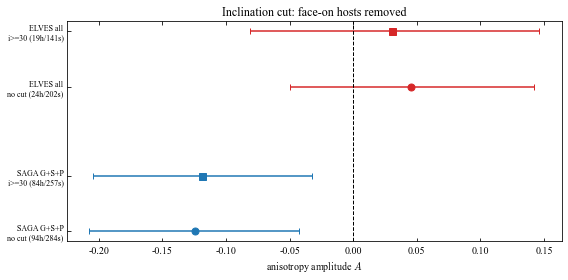

In [12]:
pairs = [
    ("SAGA G+S+P", "SAGA Gold+Silver+Part", "SAGA G+S+P (incl cut)", SAGA_C),
    ("ELVES all",  "ELVES all hosts",       "ELVES all (incl cut)",  ELVES_C),
]
fig, ax = plt.subplots(figsize=(8, 4))
y = 0; yt, yl = [], []
for name, base, cut, col in pairs:
    for lab, mark, sub in [(base, "o", "no cut"), (cut, "s", f"i>={INCL_MIN_DEG:.0f}")]:
        f = results[lab]["fit_all"]; r = results[lab]
        ax.errorbar(f["A"], y, xerr=[[f["A"] - f["lo"]], [f["hi"] - f["A"]]],
                    fmt=mark, color=col, capsize=3, ms=7)
        yt.append(y); yl.append(f"{name}\n{sub} ({r['n_host']}h/{r['n_sat']}s)")
        y += 1
    y += 0.6
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_yticks(yt); ax.set_yticklabels(yl, fontsize=8)
ax.set_xlabel(r"anisotropy amplitude $A$"); ax.set_title("Inclination cut: face-on hosts removed")
ax.tick_params(which="both", direction="in", top=True)
plt.tight_layout(); plt.show()

## Plot 4 — quench-fraction sinusoid fits (runs with both classes)

The quench-fraction anisotropy $f_q(\theta)=a+b\cos2\theta$ (as in `03_analysis`) for every run
where quenched and star-forming satellites coexist — i.e. all SAGA runs and all ELVES runs (the
satellite quench proxy `ETG?` is unaffected by removing early-type *hosts*).

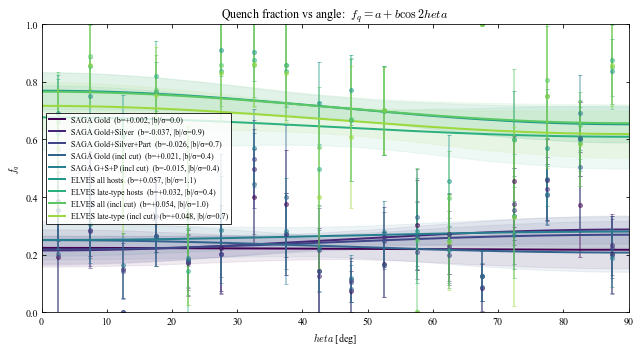

In [13]:
def fq_band(p, e, n_mc=5000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 300)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    yy = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    return np.degrees(x), a.mean() + b.mean() * np.cos(2 * x), np.percentile(yy, 16, 0), np.percentile(yy, 84, 0)

have_fq = [l for l, _, _ in RUNS if results[l]["fq_p"] is not None and np.isfinite(results[l]["fq_p"][1])]
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.cm.viridis(np.linspace(0, 0.85, len(have_fq)))
for lab, c in zip(have_fq, cmap):
    r = results[lab]
    ax.errorbar(ANGLE_CENTERS, r["fq_mean"], yerr=r["fq_std"], fmt="o", color=c, capsize=2, ms=4, alpha=0.5)
    x, ymed, ylo, yhi = fq_band(r["fq_p"], r["fq_e"])
    sig = abs(r["fq_p"][1] / r["fq_e"][1])
    ax.plot(x, ymed, color=c, lw=2, label=f"{lab}  (b={r['fq_p'][1]:+.3f}, |b|/σ={sig:.1f})")
    ax.fill_between(x, ylo, yhi, color=c, alpha=0.08)
ax.set_xlim(0, 90); ax.set_ylim(0, 1)
ax.set_xlabel(r"$	heta$ [deg]"); ax.set_ylabel(r"$f_q$")
ax.set_title(r"Quench fraction vs angle:  $f_q=a+b\cos 2	heta$")
ax.legend(fontsize=8, fancybox=False, edgecolor="k")
ax.tick_params(which="both", direction="in", top=True, right=True)
plt.tight_layout(); plt.show()

## Takeaways

* **Counts per run** are in the summary table and annotated on every figure — the SAGA grade
  ladder (Gold → +Silver → +Participation) and the inclination cut trade sample size against
  purity.
* **$A$** (spatial anisotropy) is reported for every variation, alongside the quench-fraction `b`.
* **Early-type host removal** drops NGC1023, NGC3115, NGC3379, M104 (and Cen A, which has no
  in-$R_{200}$ satellites here) together with their satellites; compare the `ELVES all hosts` and
  `ELVES late-type hosts` rows to see whether those hosts drive the signal.
* **Inclination cut** removes face-on hosts (ill-defined major axis); Plot 3 shows whether the
  amplitude sharpens once they are dropped.

Edit `INCL_MIN_DEG` to change the face-on threshold, or extend `RUNS` with further selections.